In [ ]:
import random
import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.utils import array_to_img
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization, Conv2DTranspose
import os
from PIL import Image
import cv2

In [ ]:
import random
import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.utils import array_to_img
from tensorflow.keras import layers, models
import os
from PIL import Image
import cv2

def resize_image(folder_path, target_size=(480, 256)):
    """
    Redimensionne toutes les images dans un dossier unique et écrase les fichiers originaux
    si nécessaire (sauf si l'image a déjà la bonne taille).

    :param folder_path: Chemin du dossier contenant toutes les images.
    :param target_size: Taille cible (largeur, hauteur).
    """
    resized_count = 0

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')) and '_aug_' not in filename:
            image_path = os.path.join(folder_path, filename)

            with Image.open(image_path) as img:
                if img.size == target_size:
                    print(f"✅ {filename} est déjà à la bonne taille.")
                    continue

                img_resized = img.resize(target_size, Image.LANCZOS)
                img_resized.save(image_path)
                resized_count += 1
                print(f"🔧 {filename} redimensionnée avec succès.")

    if resized_count == 0:
        print("😴 Aucune image redimensionnée : toutes les images sont déjà à la bonne taille.")
    else:
        print(f"🎯 {resized_count} image(s) redimensionnée(s) avec succès.")

input_dir = r"/home/full_datas"
output_dir = r"/home/full_resized_datas"

resize_image(input_dir, (1920,1024))

🔧 9um 2_4555.jpg redimensionnée avec succès.
🔧 9um 2_4623.jpg redimensionnée avec succès.
🔧 PMMA +inp PHOTOSENSIBLE 30s_088_1.jpg redimensionnée avec succès.
🔧 9um 2_4615.jpg redimensionnée avec succès.
🔧 Extim500.5gain3.2xred2.67blu4.54-5x_5014.jpg redimensionnée avec succès.
🔧 Extim500.5gain3.2xred2.67blu4.54-5x_4996.jpg redimensionnée avec succès.
🔧 8s-gain 1x-5X-red2.43-bleu8.3contrast 1_5251.jpg redimensionnée avec succès.
🔧 PMMA +inp PHOTOSENSIBLE 30s_052.jpg redimensionnée avec succès.
🔧 Extim500.5gain3.2xred2.67blu4.54-5x_4995.jpg redimensionnée avec succès.
🔧 Extime643.9ms-gain3.2x-5X- red267_4797.jpg redimensionnée avec succès.
🔧 Extim500.5gain3.2xred2.67blu4.54-5x_5030.jpg redimensionnée avec succès.
🔧 PMMA +inp PHOTOSENSIBLE 30s_025.jpg redimensionnée avec succès.
🔧 Extime643.9ms-gain3.2x-5X- red2.67 bleu2.47_4832.jpg redimensionnée avec succès.
🔧 9um 2_4554.jpg redimensionnée avec succès.
🔧 Extim500.5gain3.2xred2.67blu4.54-5x_4953_1734079376838.jpg redimensionnée avec succ

In [ ]:
def detect_and_crop_circle(image_path, base_output_dir, dp=1.2, min_dist=1200, param1=100, param2=10, min_radius=400, max_radius=800):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Erreur: Impossible de charger l'image {image_path}.")
        return None

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Détection de cercle
    circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=dp, minDist=min_dist,
                               param1=param1, param2=param2, minRadius=min_radius, maxRadius=max_radius)

    height, width = gray.shape
    center_x, center_y = width // 2, height // 2

    best_circle = None
    min_distance = float("inf")

    if circles is not None:
        for circle in circles[0, :]:
            x, y, r = circle
            distance = np.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
            if distance < min_distance:
                min_distance = distance
                best_circle = circle

    if best_circle is not None:
        x, y, r = map(int, best_circle)
        x1, y1 = max(0, x - r), max(0, y - r)
        x2, y2 = min(image.shape[1], x + r), min(image.shape[0], y + r)

        cropped = gray[y1:y2, x1:x2]

        os.makedirs(base_output_dir, exist_ok=True)
        output_path = os.path.join(base_output_dir, os.path.basename(image_path))
        cv2.imwrite(output_path, cropped)

        print(f"✅ Image recadrée sauvegardée : {output_path}")
        return output_path

    print(f"❌ Aucun cercle détecté dans : {image_path}")
    return None

def crop_all_images(input_dir, output_dir):
    for image_name in os.listdir(input_dir):
        image_path = os.path.join(input_dir, image_name)
        if os.path.isfile(image_path):
            detect_and_crop_circle(image_path, base_output_dir=output_dir)

output_dir1 = r"/home/full_cropped_datas"

crop_all_images(input_dir,output_dir1)

✅ Image recadrée sauvegardée : /home/full_cropped_datas/9um 2_4555.jpg
✅ Image recadrée sauvegardée : /home/full_cropped_datas/9um 2_4623.jpg
✅ Image recadrée sauvegardée : /home/full_cropped_datas/PMMA +inp PHOTOSENSIBLE 30s_088_1.jpg
✅ Image recadrée sauvegardée : /home/full_cropped_datas/9um 2_4615.jpg
✅ Image recadrée sauvegardée : /home/full_cropped_datas/Extim500.5gain3.2xred2.67blu4.54-5x_5014.jpg
✅ Image recadrée sauvegardée : /home/full_cropped_datas/Extim500.5gain3.2xred2.67blu4.54-5x_4996.jpg
✅ Image recadrée sauvegardée : /home/full_cropped_datas/8s-gain 1x-5X-red2.43-bleu8.3contrast 1_5251.jpg
❌ Aucun cercle détecté dans : /home/full_datas/PMMA +inp PHOTOSENSIBLE 30s_052.jpg
✅ Image recadrée sauvegardée : /home/full_cropped_datas/Extim500.5gain3.2xred2.67blu4.54-5x_4995.jpg
✅ Image recadrée sauvegardée : /home/full_cropped_datas/Extime643.9ms-gain3.2x-5X- red267_4797.jpg
✅ Image recadrée sauvegardée : /home/full_cropped_datas/Extim500.5gain3.2xred2.67blu4.54-5x_5030.jpg
❌ 

In [ ]:
def charger_images(chemin_dossier, taille_image=(480, 256), batch_size=32, validation_split=0.2):
    """
    Charge les images depuis un dossier (sans sous-dossiers), les redimensionne,
    et les divise en ensembles d'entraînement et de validation pour un autoencodeur.

    Args:
        chemin_dossier (str): Dossier contenant toutes les images (sans sous-dossiers).
        taille_image (tuple): Redimensionnement de chaque image.
        batch_size (int): Nombre d'images par lot.
        validation_split (float): Fraction des données à utiliser pour la validation.

    Returns:
        (x_train, x_val): tableaux numpy pour entraînement et validation.
    """
    # Chargement du dataset
    dataset = tf.keras.utils.image_dataset_from_directory(
        chemin_dossier,
        image_size=taille_image,
        color_mode='rgb',
        batch_size=batch_size,
        label_mode=None,
        shuffle=True,
        validation_split=validation_split,
        subset='training',
        seed=42
    )

    # Récupération des images sous forme de tableaux NumPy
    images = np.concatenate([batch.numpy() for batch in dataset])

    # Normalisation des pixels entre 0 et 1
    images = images.astype("float32") / 255.0

    # Division entraînement / validation
    x_train, x_val = train_test_split(images, test_size=validation_split, random_state=42)

    return x_train, x_val

x_train, x_val = charger_images(r"/content/drive/MyDrive/fullagregats", (128,128), 8, 0.2)

Found 65 files.
Using 52 files for training.


In [ ]:
def creer_autoencodeur(input_shape):
    """
    Crée un autoencodeur convolutionnel simple.

    Args:
        input_shape (tuple): Dimensions des images d'entrée.

    Returns:
        autoencoder (tf.keras.Model): Modèle compilé prêt à l'entraînement.
    """
    input_img = layers.Input(shape=input_shape)

    # --- ENCODEUR ---
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)  # 32x32

    x = layers.Conv2D(128, (1, 1), activation='relu')(x)  # ← dense spatialement

    # --- DECODEUR ---
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)  # 64x64
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(input_img, decoded)
    optimizer = Adam(learning_rate=1e-3)
    autoencoder.compile(optimizer=optimizer, loss='mse',  metrics=["accuracy"])  # MSE bien adapté pour reconstruction

    return autoencoder

# Créer le modèle
autoencoder = creer_autoencodeur(input_shape=(128,128,3))

autoencoder.summary()

# Entraînement
history = autoencoder.fit(
    x_train, x_train,
    epochs=30,
    batch_size=8,
    validation_data=(x_val, x_val)
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 128, 128, 32)   │        36,896 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,305 (165.25 KB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 446ms/step - accuracy: 0.0968 - loss: 0.1285 - val_accuracy: 0.1173 - val_loss: 0.1569
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0922 - loss: 0.1105 - val_accuracy: 0.1173 - val_loss: 0.1296
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0884 - loss: 0.0854 - val_accuracy: 0.1173 - val_loss: 0.0921
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0954 - loss: 0.0807 - val_accuracy: 0.1173 - val_loss: 0.0657
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0896 - loss: 0.0632 - val_accuracy: 0.1173 - val_loss: 0.0587
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0960 - loss: 0.0540 - val_accuracy: 0.1173 - val_loss: 0.0401
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0878 - loss: 0.0397 - val_accuracy: 0.1173 - val_loss: 0.0256
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0949 - loss: 0.0300 - val_accuracy: 0.1173 - val_loss: 0.0160

/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


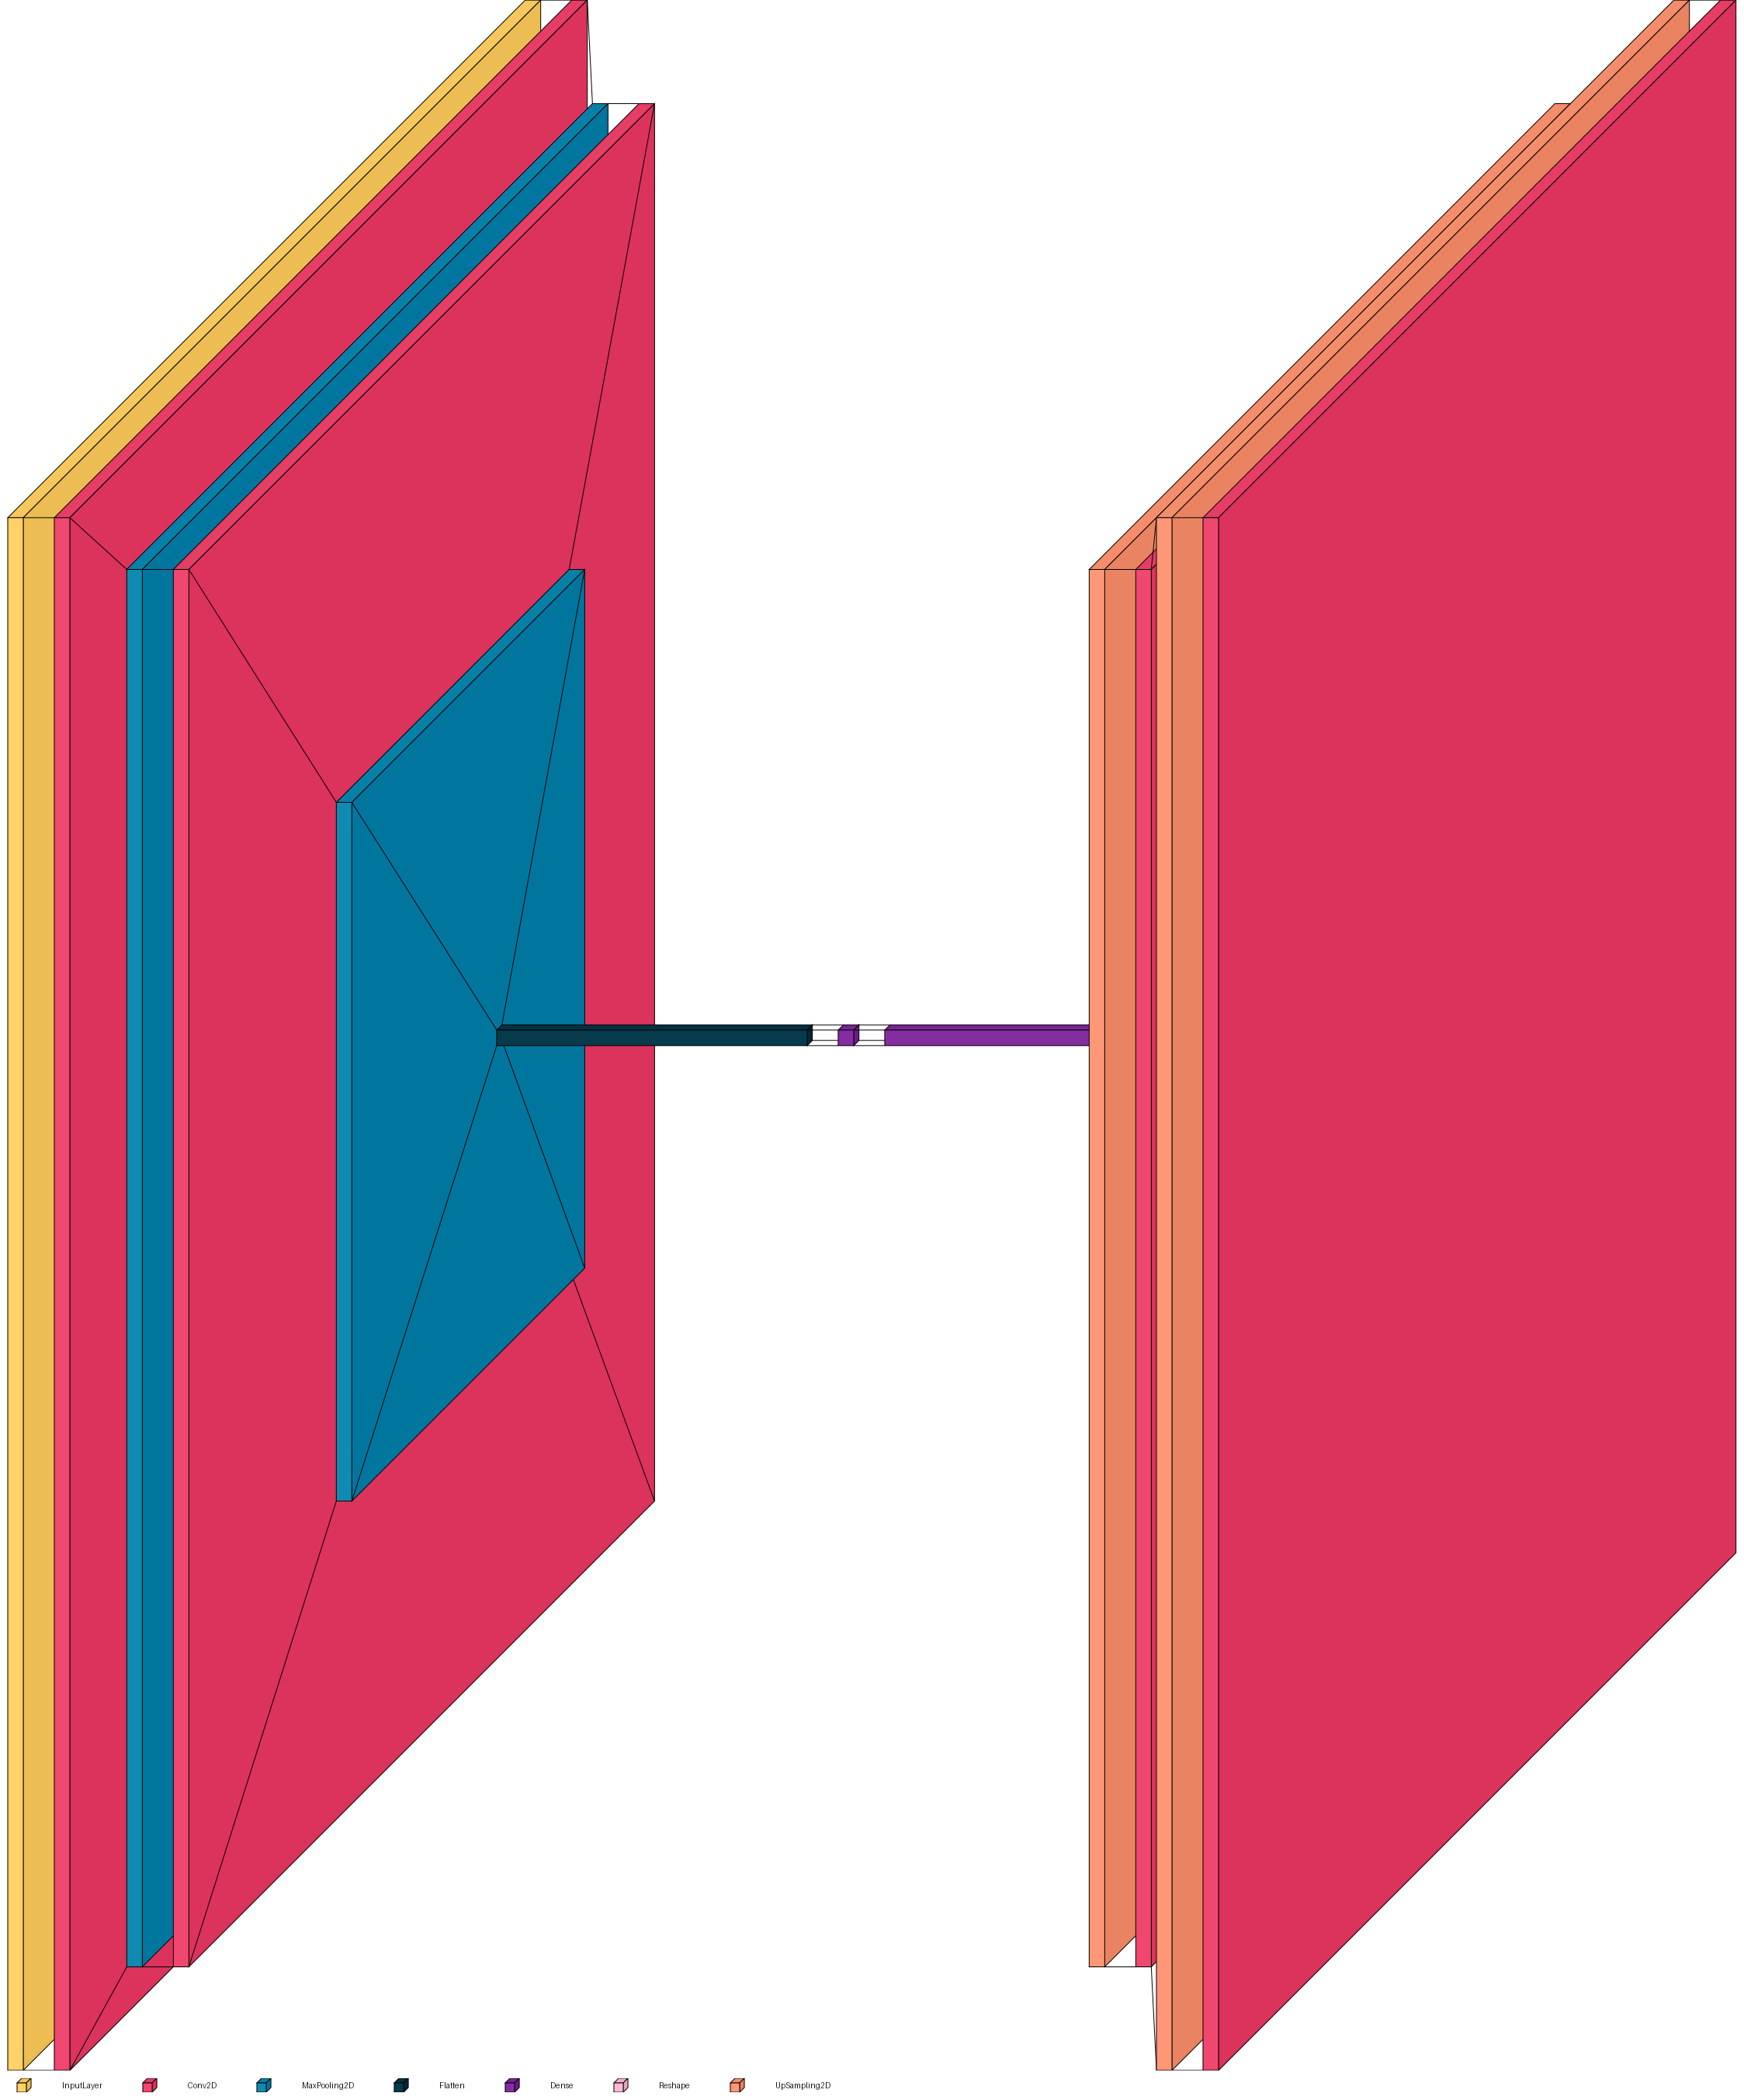

In [ ]:
from PIL import ImageFont

visualkeras.layered_view(
    autoencoder,
    legend=True,
    draw_volume=True,
    spacing=40
)

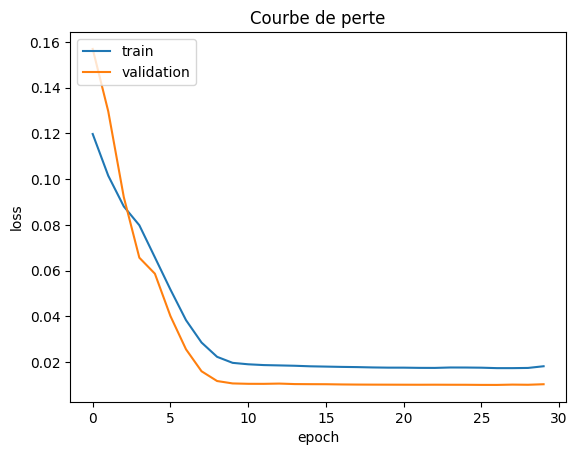

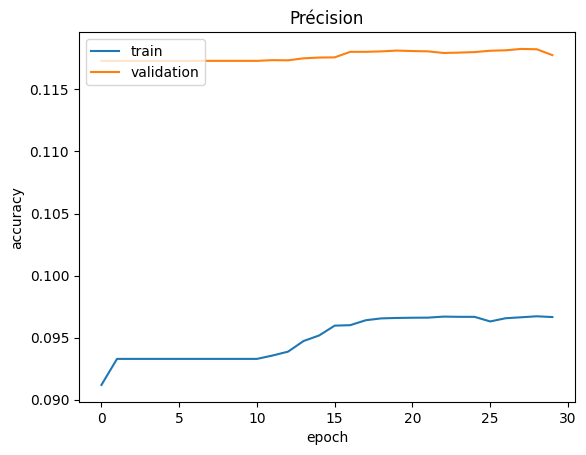

In [ ]:
def plt_metric(history, metric, title, has_valid=True):
    """Affiche le métriques données depuis l'hystory.

    Arguments:
        history: history attribute of History object returned from Model.fit.
        metric: Metric to plot, a string value present as key in 'history'.
        title: A string to be used as title of plot.
        has_valid: Boolean, true if valid data was passed to Model.fit else false.

    Returns:
        None.
    """
    plt.plot(history[metric])
    if has_valid:
        plt.plot(history["val_" + metric])
        plt.legend(["train", "validation"], loc="upper left")
    plt.title(title)
    plt.ylabel(metric)
    plt.xlabel("epoch")
    plt.show()

plt_metric(history.history, metric="loss", title="Courbe de perte", has_valid=True)

plt_metric(history.history, metric="accuracy", title="Précision", has_valid=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step


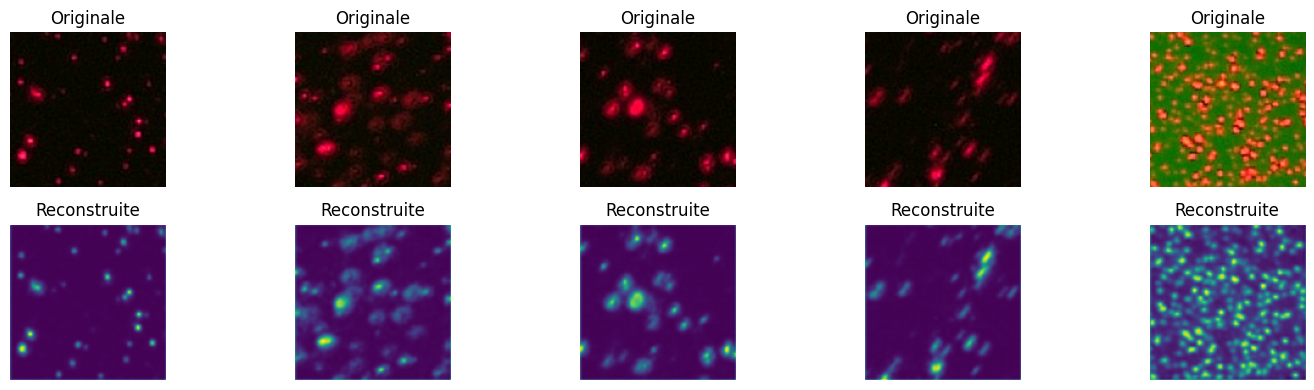

In [ ]:
def afficher_reconstructions(autoencoder, images, n=5):
    """
    Affiche n images originales et leur reconstruction par l'autoencodeur.

    Args:
        autoencoder (Model): Le modèle entraîné.
        images (np.array): Images d'entrée à reconstruire.
        n (int): Nombre d'images à afficher.
    """
    reconstructions = autoencoder.predict(images[:n])

    plt.figure(figsize=(15, 4))
    for i in range(n):
        # Image originale
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(images[i])
        plt.title("Originale")
        plt.axis("off")

        # Reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructions[i])
        plt.title("Reconstruite")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

images_test = x_val[:5]

afficher_reconstructions(autoencoder, images_test)

In [ ]:
from PIL import Image
from tensorflow.keras.preprocessing.image import img_to_array


def calculer_mse_image(autoencoder, image):
    """
    Calcule l'erreur quadratique moyenne (MSE) entre l'image et sa reconstruction.

    image : doit être de taille (hauteur, largeur, canaux)
    """
    image = np.expand_dims(image, axis=0)  # Ajouter batch size
    reconstruction = autoencoder.predict(image, verbose=0)
    mse = np.mean(np.square(image - reconstruction))
    return mse

image = load_img(r"/content/drive/MyDrive/Bichon-maltais.jpg")
image = img_to_array(image) / 255.0  # Normaliser

image_test1 = x_val[0]
image_test2 = x_val[1]
image_test3 = x_val[2]
image_test4 = x_val[3]
image_test5 = x_val[4]

print("erreur de reconstruction de l'image: ", calculer_mse_image(autoencoder, image))
print("erreur de reconstruction de l'image: ", calculer_mse_image(autoencoder, image_test1))
print("erreur de reconstruction de l'image: ", calculer_mse_image(autoencoder, image_test2))
print("erreur de reconstruction de l'image: ", calculer_mse_image(autoencoder, image_test3))
print("erreur de reconstruction de l'image: ", calculer_mse_image(autoencoder, image_test4))
print("erreur de reconstruction de l'image: ", calculer_mse_image(autoencoder, image_test5))

# Charger et redimensionner l'image avec PIL
image_path = "/content/drive/MyDrive/Bichon-maltais.jpg"
image1 = Image.open(image_path).convert("RGB")
image1 = image.resize((900, 900))  # Redimensionnement explicite
image1 = img_to_array(image1) / 255.0  # Normaliser entre 0 et 1

afficher_reconstructions(autoencoder, [image1], n=1)

ValueError: Input 0 of layer "functional" is incompatible with the layer: expected shape=(None, 128, 128, 3), found shape=(1, 256, 384, 3)

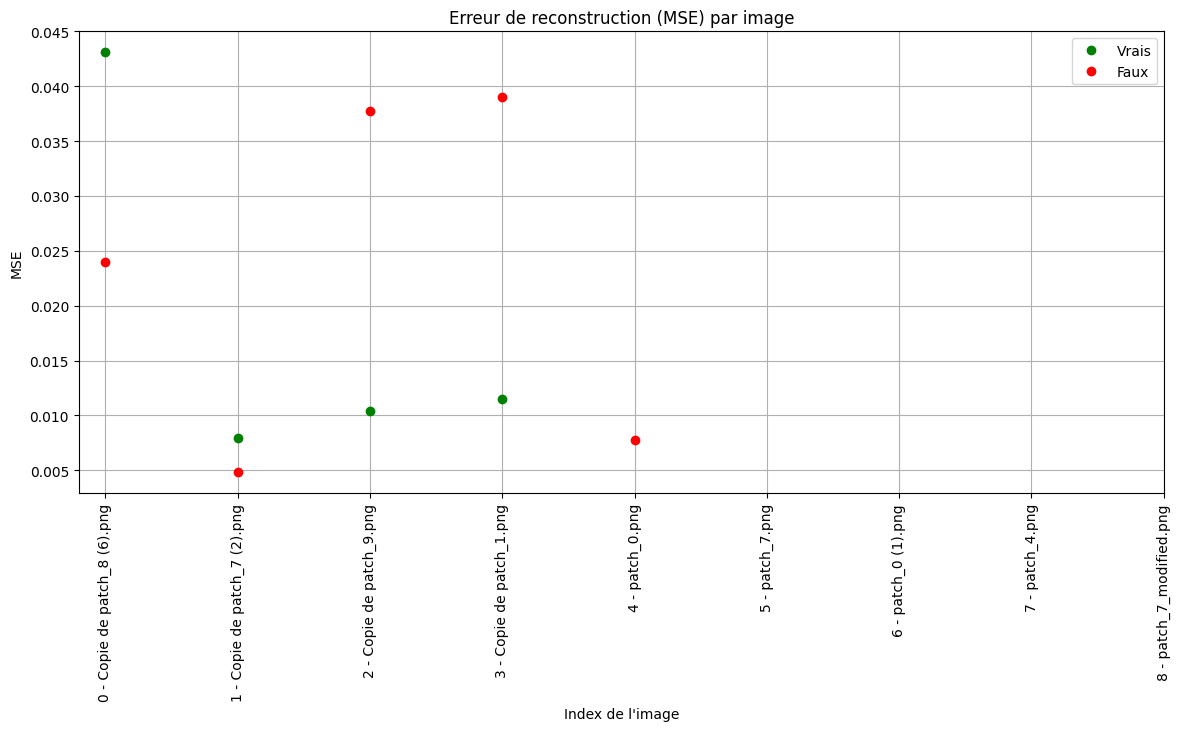

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing.image import img_to_array

def charger_images_dossier(dossier, taille=(128, 128)):
    images = []
    noms_fichiers = []
    for nom in os.listdir(dossier):
        chemin = os.path.join(dossier, nom)
        if nom.lower().endswith((".png", ".jpg", ".jpeg")):
            try:
                img = Image.open(chemin)
                img = img.resize(taille, Image.Resampling.LANCZOS)
                img_array = img_to_array(img) / 255.0
                images.append(img_array)
                noms_fichiers.append(nom)
            except Exception as e:
                print(f"Erreur lors du chargement de {nom} : {e}")
    return np.array(images), noms_fichiers

def calculer_mse_image(autoencoder, image):
    image = np.expand_dims(image, axis=0)
    reconstruction = autoencoder.predict(image, verbose=0)
    mse = np.mean(np.square(image - reconstruction))
    return mse

def afficher_mse(autoencoder, dossier_vrais, dossier_faux):
    images_vrais, noms_vrais = charger_images_dossier(dossier_vrais)
    images_faux, noms_faux = charger_images_dossier(dossier_faux)

    noms = noms_vrais + noms_faux
    labels = ["vrais"] * len(noms_vrais) + ["Faux"] * len(noms_faux)

    mse_vrais = [calculer_mse_image(autoencoder, img) for img in images_vrais]
    mse_faux = [calculer_mse_image(autoencoder, img) for img in images_faux]

    # Affichage
    plt.figure(figsize=(14, 6))
    plt.plot(mse_vrais, 'go', label='Vrais')
    plt.plot(mse_faux, 'ro', label='Faux')
    plt.xticks(ticks=range(len(noms)), labels=[f"{i} - {n}" for i, n in enumerate(noms)], rotation=90)
    plt.title("Erreur de reconstruction (MSE) par image")
    plt.xlabel("Index de l'image")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.show()

    return mse_vrais, mse_faux

# Exemple d'utilisation
dossier_vrais = "/content/drive/MyDrive/vraisagregats"
dossier_faux = "/content/drive/MyDrive/Fauxagregates"

mse_vrais, mse_faux = afficher_mse(autoencoder, dossier_vrais, dossier_faux)
